#排列重要性 Permutation Importance


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from matplotlib.patches import Patch
import joblib
import time
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data loaded")
print(f"Features: {X.shape[1]}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# 加载已训练的模型
try:
    best_dt = joblib.load('../models/day03_best_tree.pkl')
    best_rf = joblib.load('../models/day09_random_forest_tuned.pkl')
    print("\nLoaded DT and RF models")
except:
    print("\nModels not found, training new ones...")
    best_dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
    best_dt.fit(X_train, y_train)
    
    best_rf = RandomForestRegressor(n_estimators=200, max_depth=20, 
                                     max_features='sqrt', random_state=42, n_jobs=-1)
    best_rf.fit(X_train, y_train)
    print("Models trained")

# 评估基准性能
print(f"\nBaseline:")
print(f"  DT test R²: {best_dt.score(X_test, y_test):.4f}")
print(f"  RF test R²: {best_rf.score(X_test, y_test):.4f}")

Data loaded
Features: 135
Train: 3811 | Test: 953

Loaded DT and RF models

Baseline:
  DT test R²: 0.5781
  RF test R²: 0.6972


In [13]:
# 计算三种特征重要性
print("\n" + "="*70)
print("方法 1：决策树内置特征重要性（基于基尼不纯度）")
print("="*70)

dt_importances = best_dt.feature_importances_

dt_imp_df = pd.DataFrame({
    'feature': X.columns,
    'DT_importance': dt_importances
}).sort_values('DT_importance', ascending=False)

print("\nTop 10 特征（决策树）:\n")
print(dt_imp_df.head(10).to_string(index=False))


方法 1：决策树内置特征重要性（基于基尼不纯度）

Top 10 特征（决策树）:

                             feature  DT_importance
MagpieData maximum Electronegativity       0.410915
                             density       0.241587
        MagpieData avg_dev NpValence       0.054984
           MagpieData mean NpValence       0.036105
  MagpieData maximum MendeleevNumber       0.033551
   MagpieData mode Electronegativity       0.022027
   MagpieData minimum CovalentRadius       0.017542
  MagpieData range Electronegativity       0.015052
          MagpieData mean NdUnfilled       0.014792
                                 vpa       0.014657


In [14]:
# 随机森林内中重要性
print("\n" + "="*70)
print("方法 2：随机森林内置特征重要性")
print("="*70)

rf_importances = best_rf.feature_importances_

rf_imp_df = pd.DataFrame({
    'feature': X.columns,
    'RF_importance': rf_importances
}).sort_values('RF_importance', ascending=False)

print("\nTop 10 特征（随机森林）:\n")
print(rf_imp_df.head(10).to_string(index=False))


方法 2：随机森林内置特征重要性

Top 10 特征（随机森林）:

                             feature  RF_importance
MagpieData maximum Electronegativity       0.150941
                             density       0.125096
         MagpieData minimum MeltingT       0.111287
            MagpieData mode MeltingT       0.054598
   MagpieData minimum CovalentRadius       0.031467
            MagpieData mean MeltingT       0.028075
MagpieData avg_dev Electronegativity       0.014823
           MagpieData mean NpValence       0.014179
                                 vpa       0.013718
        MagpieData avg_dev NpValence       0.013422


In [15]:
#Permutation Importance
print("\n" + "="*70)
print("方法 3：Permutation Importance（排列重要性）")
print("="*70)

print("\n⚠️  Permutation Importance 计算较慢，预计需要 2-5 分钟...")
print("正在计算...")

# 对随机森林计算 Permutation Importance
start_time = time.time()

perm_importance_rf = permutation_importance(
    best_rf,           # 模型
    X_test,            # 用测试集（重要！）
    y_test,
    n_repeats=10,      # 每个特征打乱 10 次取平均
    random_state=42,
    n_jobs=-1,         # 并行加速
    scoring='r2'       # 用 R² 作为评估指标
)

calc_time = time.time() - start_time
print(f"✓ 计算完成，耗时 {calc_time:.2f} 秒")

# 整理结果
perm_imp_rf_df = pd.DataFrame({
    'feature': X.columns,
    'Perm_importance_mean': perm_importance_rf.importances_mean,
    'Perm_importance_std': perm_importance_rf.importances_std
}).sort_values('Perm_importance_mean', ascending=False)

print("\nTop 10 特征（Permutation - 随机森林）:\n")
print(perm_imp_rf_df.head(10).to_string(index=False))

# 同样对决策树计算（更快）
print("\n正在计算决策树的 Permutation Importance...")
perm_importance_dt = permutation_importance(
    best_dt, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_imp_dt_df = pd.DataFrame({
    'feature': X.columns,
    'Perm_importance_DT': perm_importance_dt.importances_mean
}).sort_values('Perm_importance_DT', ascending=False)

print("✓ 完成")


方法 3：Permutation Importance（排列重要性）

⚠️  Permutation Importance 计算较慢，预计需要 2-5 分钟...
正在计算...


✓ 计算完成，耗时 19.53 秒

Top 10 特征（Permutation - 随机森林）:

                             feature  Perm_importance_mean  Perm_importance_std
                             density              0.184960             0.020560
MagpieData maximum Electronegativity              0.075780             0.005485
         MagpieData minimum MeltingT              0.038090             0.003834
            MagpieData mean MeltingT              0.018841             0.002422
                                 vpa              0.014078             0.001813
           MagpieData mean NpValence              0.009334             0.001236
  MagpieData maximum MendeleevNumber              0.007313             0.001238
MagpieData avg_dev Electronegativity              0.006286             0.001583
           MagpieData mean NdValence              0.006200             0.000535
            MagpieData mode MeltingT              0.006096             0.001367

正在计算决策树的 Permutation Importance...
✓ 完成


In [16]:
# 合并对比三种方法
print("\n" + "="*70)
print("Three Methods Comparison")
print("="*70)

# 合并三个 DataFrame
comparison_all = dt_imp_df.merge(
    rf_imp_df, on='feature'
).merge(
    perm_imp_rf_df[['feature', 'Perm_importance_mean', 'Perm_importance_std']], 
    on='feature'
)

# 重命名列（简化）
comparison_all = comparison_all.rename(columns={
    'DT_importance': 'DT_Gini',
    'RF_importance': 'RF_Gini',
    'Perm_importance_mean': 'RF_Perm',
    'Perm_importance_std': 'RF_Perm_std'
})

# 按 Permutation 重要性排序（最可靠的方法）
comparison_all = comparison_all.sort_values('RF_Perm', ascending=False).reset_index(drop=True)

# 添加排名列
comparison_all['Rank_DT'] = comparison_all['DT_Gini'].rank(ascending=False).astype(int)
comparison_all['Rank_RF'] = comparison_all['RF_Gini'].rank(ascending=False).astype(int)
comparison_all['Rank_Perm'] = comparison_all['RF_Perm'].rank(ascending=False).astype(int)

# 添加排名变化列（Permutation vs RF）
comparison_all['Rank_change'] = comparison_all['Rank_RF'] - comparison_all['Rank_Perm']

print("\nTop 15 features (sorted by Permutation importance):\n")
print(comparison_all.head(15)[
    ['feature', 'DT_Gini', 'RF_Gini', 'RF_Perm', 'RF_Perm_std', 
     'Rank_DT', 'Rank_RF', 'Rank_Perm', 'Rank_change']
].to_string(index=False))

# 找出差异最大的特征
print("\n" + "="*70)
print("Difference Analysis")
print("="*70)

# 找出内置重要性高但 Permutation 低的特征（可能是虚高）
comparison_all['Gini_Perm_diff'] = comparison_all['RF_Gini'] - comparison_all['RF_Perm']
suspicious_features = comparison_all[comparison_all['Gini_Perm_diff'] > 0.05].sort_values(
    'Gini_Perm_diff', ascending=False
)

if len(suspicious_features) > 0:
    print(f"\nSuspicious features (RF_Gini >> RF_Perm): {len(suspicious_features)} found\n")
    print(suspicious_features[['feature', 'RF_Gini', 'RF_Perm', 'Gini_Perm_diff']].head(5).to_string(index=False))

# 找出排名变化最大的特征
rank_change_large = comparison_all[abs(comparison_all['Rank_change']) > 5].copy()
rank_change_large['abs_change'] = abs(rank_change_large['Rank_change'])
rank_change_large = rank_change_large.sort_values('abs_change', ascending=False)

if len(rank_change_large) > 0:
    print(f"\nLarge rank changes (|change| > 5): {len(rank_change_large)} features\n")
    print(rank_change_large[['feature', 'Rank_RF', 'Rank_Perm', 'Rank_change']].head(5).to_string(index=False))


Three Methods Comparison

Top 15 features (sorted by Permutation importance):

                             feature  DT_Gini  RF_Gini  RF_Perm  RF_Perm_std  Rank_DT  Rank_RF  Rank_Perm  Rank_change
                             density 0.241587 0.125096 0.184960     0.020560        2        2          1            1
MagpieData maximum Electronegativity 0.410915 0.150941 0.075780     0.005485        1        1          2           -1
         MagpieData minimum MeltingT 0.000000 0.111287 0.038090     0.003834       96        3          3            0
            MagpieData mean MeltingT 0.012126 0.028075 0.018841     0.002422       11        6          4            2
                                 vpa 0.014657 0.013718 0.014078     0.001813       10        9          5            4
           MagpieData mean NpValence 0.036105 0.014179 0.009334     0.001236        4        8          6            2
  MagpieData maximum MendeleevNumber 0.033551 0.012436 0.007313     0.001238        5  


绘制可视化对比图...


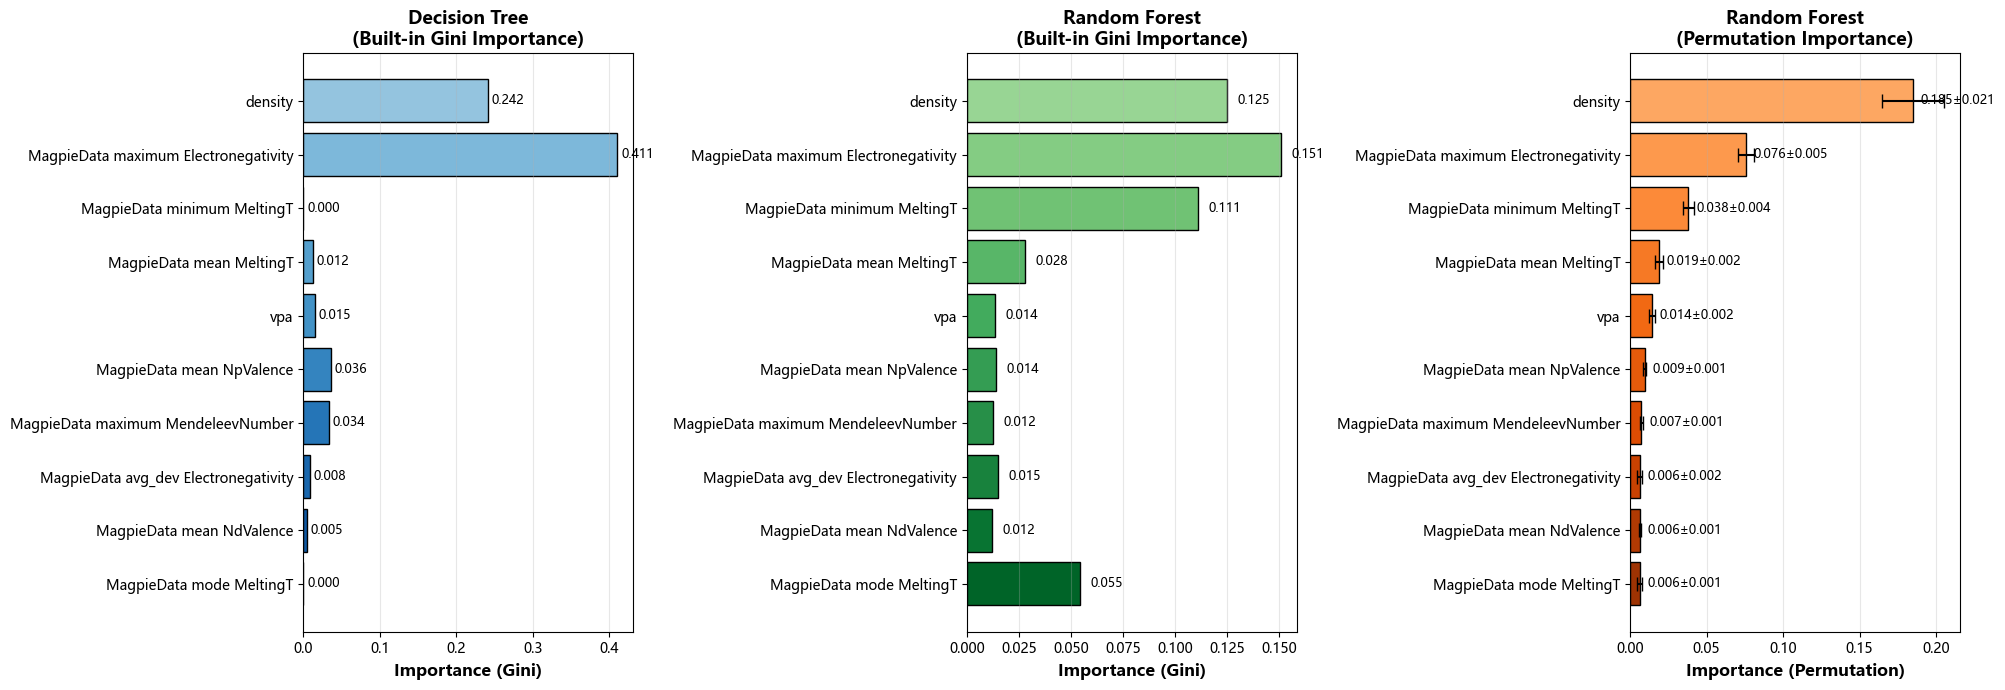

✓ 图片已保存到 ../figures/day12_three_importances_top10.png


In [17]:
# 可视化
print("\n绘制可视化对比图...")

# 准备数据
top_n = 10
comparison_top = comparison_all.head(top_n).copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 子图 1：决策树 Gini
ax1 = axes[0]
colors_dt = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
bars1 = ax1.barh(range(top_n), comparison_top['DT_Gini'], color=colors_dt, edgecolor='black')
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(comparison_top['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance (Gini)', fontsize=12, fontweight='bold')
ax1.set_title('Decision Tree\n(Built-in Gini Importance)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars1, comparison_top['DT_Gini'])):
    ax1.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

# 子图 2：随机森林 Gini
ax2 = axes[1]
colors_rf = plt.cm.Greens(np.linspace(0.4, 0.9, top_n))
bars2 = ax2.barh(range(top_n), comparison_top['RF_Gini'], color=colors_rf, edgecolor='black')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(comparison_top['feature'])
ax2.invert_yaxis()
ax2.set_xlabel('Importance (Gini)', fontsize=12, fontweight='bold')
ax2.set_title('Random Forest\n(Built-in Gini Importance)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars2, comparison_top['RF_Gini'])):
    ax2.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

# 子图 3：Permutation Importance（带误差棒）
ax3 = axes[2]
colors_perm = plt.cm.Oranges(np.linspace(0.4, 0.9, top_n))
bars3 = ax3.barh(range(top_n), comparison_top['RF_Perm'], 
                 xerr=comparison_top['RF_Perm_std'], 
                 color=colors_perm, edgecolor='black', capsize=5)
ax3.set_yticks(range(top_n))
ax3.set_yticklabels(comparison_top['feature'])
ax3.invert_yaxis()
ax3.set_xlabel('Importance (Permutation)', fontsize=12, fontweight='bold')
ax3.set_title('Random Forest\n(Permutation Importance)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

for i, (bar, val, std) in enumerate(zip(bars3, comparison_top['RF_Perm'], comparison_top['RF_Perm_std'])):
    ax3.text(val + 0.005, i, f'{val:.3f}±{std:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/day12_three_importances_top10.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图片已保存到 ../figures/day12_three_importances_top10.png")

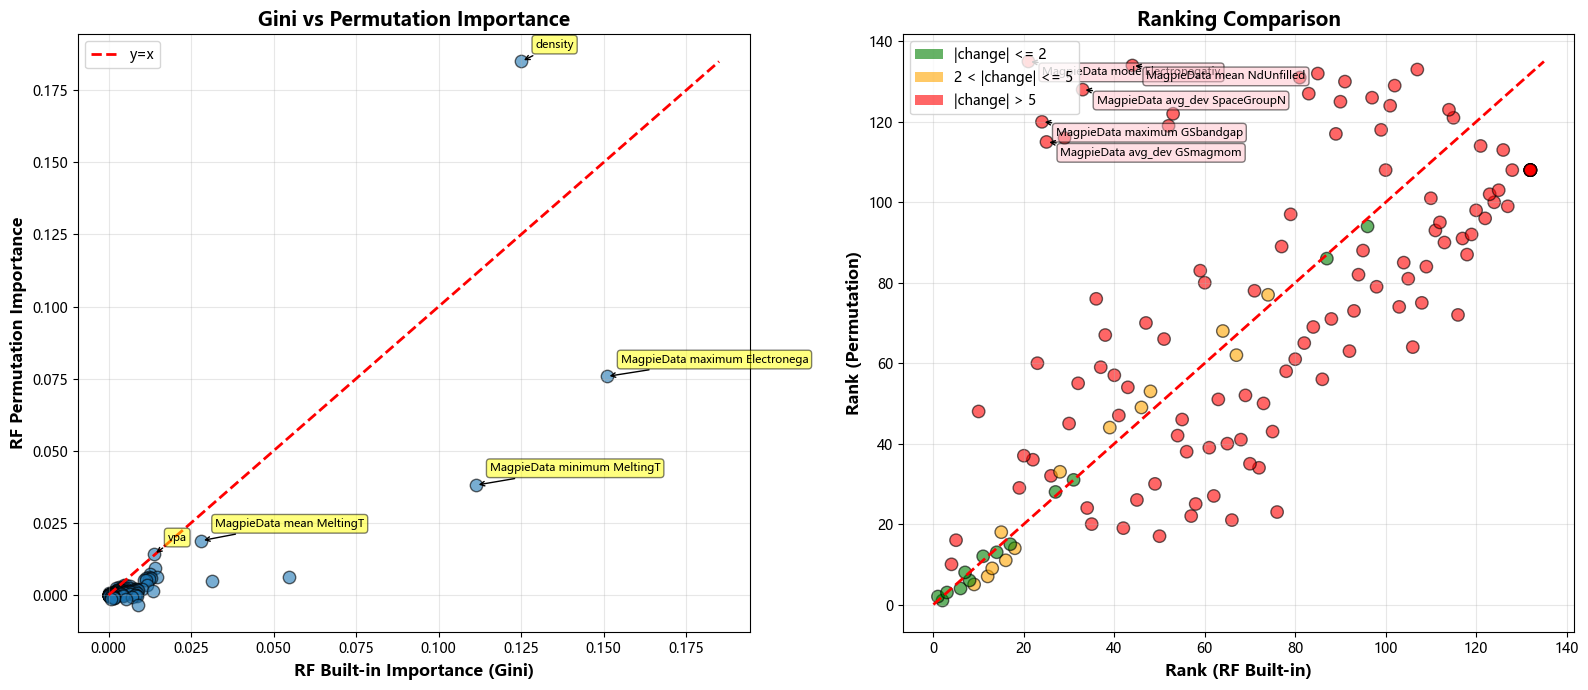

Scatter plot saved


In [18]:
# 散点图对比：RF Gini vs Permutation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：RF Gini vs RF Permutation
ax1 = axes[0]
ax1.scatter(comparison_all['RF_Gini'], comparison_all['RF_Perm'], 
            alpha=0.6, s=80, edgecolors='k')

# y=x reference
max_val = max(comparison_all['RF_Gini'].max(), comparison_all['RF_Perm'].max())
ax1.plot([0, max_val], [0, max_val], 'r--', lw=2, label='y=x')

# Annotate top 5
for i, row in comparison_all.head(5).iterrows():
    ax1.annotate(row['feature'][:30], 
                 xy=(row['RF_Gini'], row['RF_Perm']),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=8, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax1.set_xlabel('RF Built-in Importance (Gini)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RF Permutation Importance', fontsize=12, fontweight='bold')
ax1.set_title('Gini vs Permutation Importance', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：排名变化
ax2 = axes[1]
colors_rank = ['green' if abs(x) <= 2 else 'orange' if abs(x) <= 5 else 'red' 
               for x in comparison_all['Rank_change']]

ax2.scatter(comparison_all['Rank_RF'], comparison_all['Rank_Perm'], 
            c=colors_rank, alpha=0.6, s=80, edgecolors='k')
ax2.plot([0, len(comparison_all)], [0, len(comparison_all)], 'r--', lw=2)

# Annotate large changes
for i, row in rank_change_large.head(5).iterrows():
    ax2.annotate(row['feature'][:30], 
                 xy=(row['Rank_RF'], row['Rank_Perm']),
                 xytext=(10, -10), textcoords='offset points',
                 fontsize=8, bbox=dict(boxstyle='round', facecolor='pink', alpha=0.5),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax2.set_xlabel('Rank (RF Built-in)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Rank (Permutation)', fontsize=12, fontweight='bold')
ax2.set_title('Ranking Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Legend
legend_elements = [
    Patch(facecolor='green', alpha=0.6, label='|change| <= 2'),
    Patch(facecolor='orange', alpha=0.6, label='2 < |change| <= 5'),
    Patch(facecolor='red', alpha=0.6, label='|change| > 5')
]
ax2.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/day12_gini_vs_perm_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Scatter plot saved")

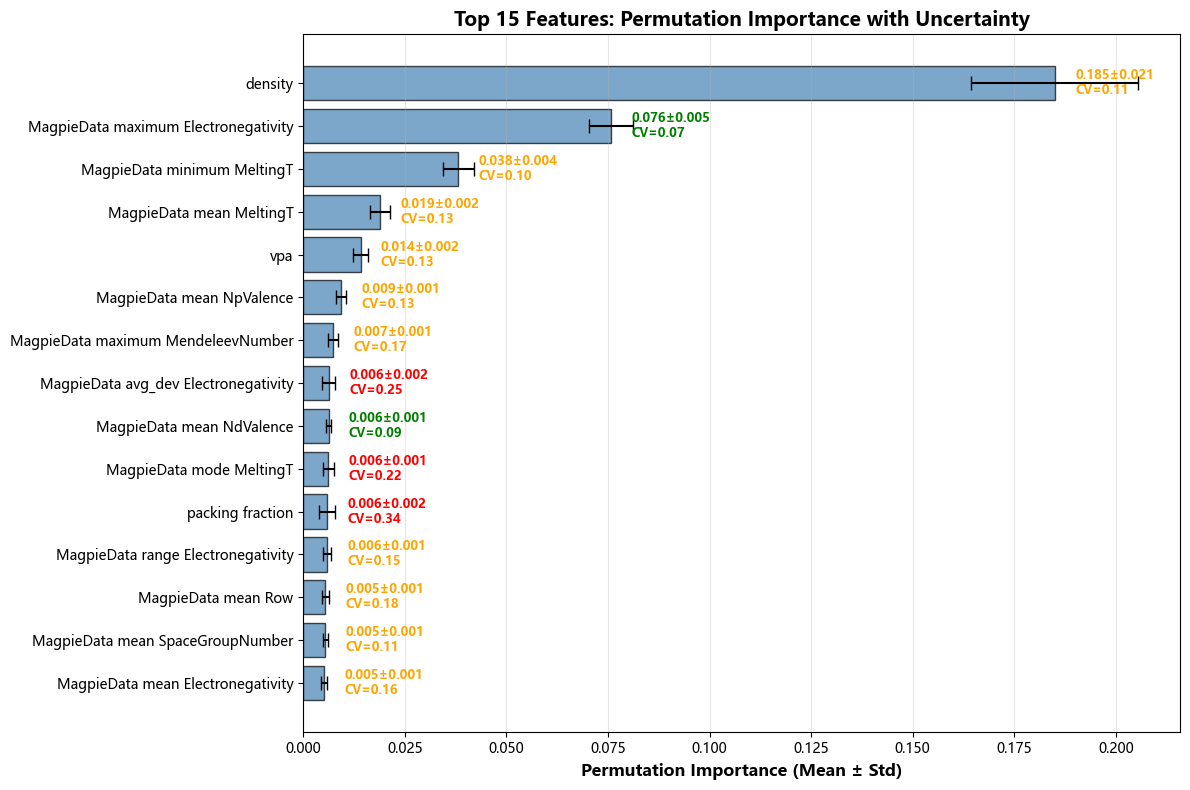

✓ 不确定性分析图已保存


In [19]:
# 可视化 Permutation Importance 的稳定性
fig, ax = plt.subplots(figsize=(12, 8))

top15 = comparison_all.head(15).copy()

# 误差棒图（水平）
y_pos = np.arange(len(top15))
ax.barh(y_pos, top15['RF_Perm'], xerr=top15['RF_Perm_std'], 
        color='steelblue', edgecolor='black', alpha=0.7, capsize=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(top15['feature'])
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (Mean ± Std)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features: Permutation Importance with Uncertainty', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, (mean, std) in enumerate(zip(top15['RF_Perm'], top15['RF_Perm_std'])):
    # 计算变异系数（CV = std / mean）
    cv = std / mean if mean > 0 else 0
    color = 'green' if cv < 0.1 else 'orange' if cv < 0.2 else 'red'
    
    ax.text(mean + 0.005, i, f'{mean:.3f}±{std:.3f}\nCV={cv:.2f}', 
            va='center', fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/day12_perm_importance_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 不确定性分析图已保存")


差异原因深入分析

分析 1：高基数特征的影响

基数 Top 10 特征:
                             feature  Cardinality  RF_Gini  RF_Perm  Gini_Perm_diff
                             density         4764 0.125096 0.184960       -0.059864
                                 vpa         4764 0.013718 0.014078       -0.000360
                    packing fraction         4764 0.011398 0.005887        0.005511
      MagpieData avg_dev GSvolume_pa         4026 0.007700 0.001989        0.005710
     MagpieData avg_dev AtomicWeight         4021 0.004229 0.001549        0.002680
         MagpieData avg_dev MeltingT         4020 0.006592 0.003306        0.003287
        MagpieData mean AtomicWeight         4020 0.005617 0.000666        0.004951
         MagpieData mean GSvolume_pa         4013 0.008736 0.001734        0.007003
            MagpieData mean MeltingT         4009 0.028075 0.018841        0.009234
MagpieData avg_dev Electronegativity         3253 0.014823 0.006286        0.008537

基数 vs (Gini - Perm) 相关系数: -0.125
✅ 

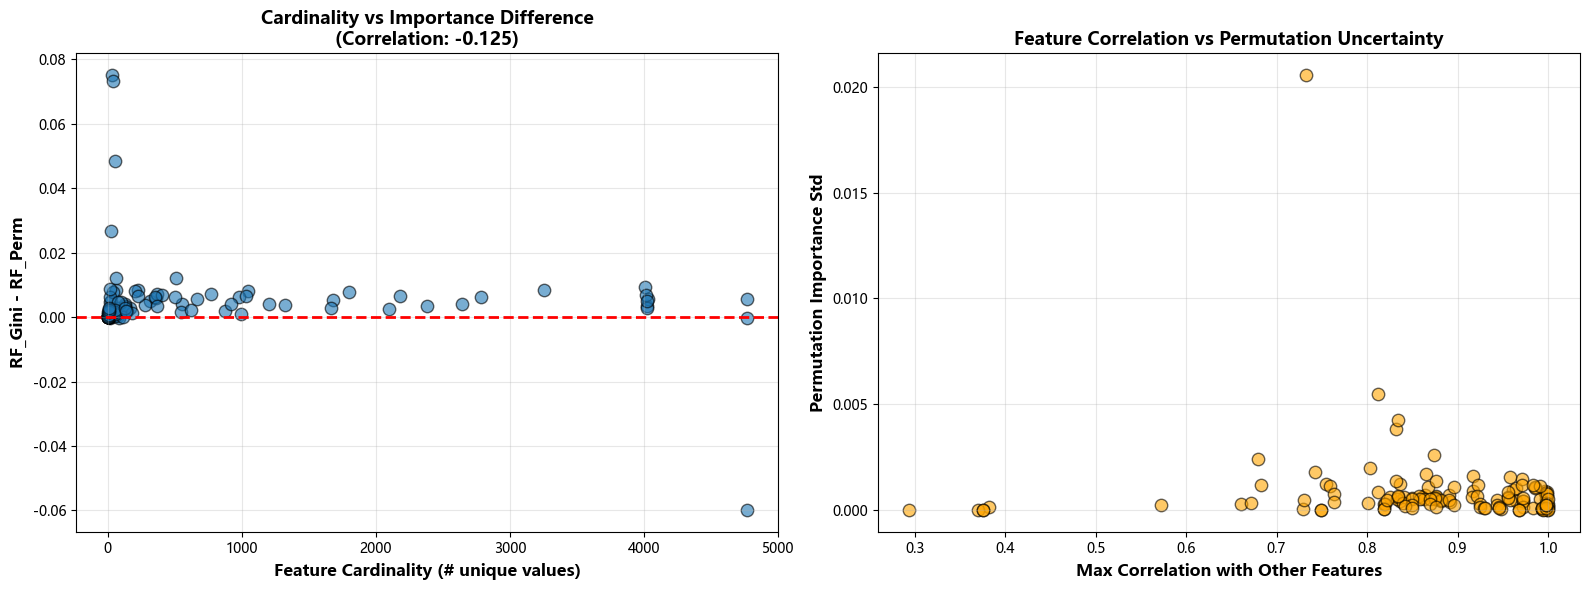


✓ 差异分析图已保存


In [20]:
print("\n" + "="*70)
print("差异原因深入分析")
print("="*70)

# 分析 1：特征的基数（唯一值数量）
feature_cardinality = {}
for col in X.columns:
    feature_cardinality[col] = X[col].nunique()

comparison_all['Cardinality'] = comparison_all['feature'].map(feature_cardinality)

# 检查高基数特征是否导致 Gini 虚高
print("\n分析 1：高基数特征的影响\n")
print("基数 Top 10 特征:")
high_card_features = comparison_all.nlargest(10, 'Cardinality')[
    ['feature', 'Cardinality', 'RF_Gini', 'RF_Perm', 'Gini_Perm_diff']
]
print(high_card_features.to_string(index=False))

# 计算相关性
corr_card_diff = comparison_all[['Cardinality', 'Gini_Perm_diff']].corr().iloc[0, 1]
print(f"\n基数 vs (Gini - Perm) 相关系数: {corr_card_diff:.3f}")
if corr_card_diff > 0.3:
    print("⚠️  基数越高，Gini 重要性越容易虚高")
else:
    print("✅ 基数对差异影响较小")

# 分析 2：特征间的相关性
print("\n分析 2：特征相关性的影响\n")
print("计算特征相关矩阵...")
feature_corr = X.corr().abs()

# 找出每个特征的最大相关系数（排除自己）
max_corr = {}
for col in X.columns:
    corr_values = feature_corr[col].drop(col)
    max_corr[col] = corr_values.max()

comparison_all['Max_Corr'] = comparison_all['feature'].map(max_corr)

# 检查高相关特征的重要性是否不稳定
high_corr_features = comparison_all[comparison_all['Max_Corr'] > 0.7].sort_values(
    'Max_Corr', ascending=False
)

if len(high_corr_features) > 0:
    print(f"发现 {len(high_corr_features)} 个高相关特征（相关系数 > 0.7）:\n")
    print(high_corr_features[['feature', 'Max_Corr', 'RF_Gini', 'RF_Perm', 'RF_Perm_std']].to_string(index=False))
    
    # 检查这些特征的 Permutation 不确定性是否更高
    avg_std_high_corr = high_corr_features['RF_Perm_std'].mean()
    avg_std_all = comparison_all['RF_Perm_std'].mean()
    print(f"\n高相关特征的平均 Perm_std: {avg_std_high_corr:.4f}")
    print(f"所有特征的平均 Perm_std: {avg_std_all:.4f}")
    
    if avg_std_high_corr > avg_std_all * 1.5:
        print("⚠️  高相关特征的 Permutation 重要性更不稳定")
    else:
        print("✅ 相关性对 Permutation 稳定性影响较小")
else:
    print("✅ 未发现强相关的特征对")

# 可视化：基数 vs 差异
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：基数 vs Gini-Perm 差异
ax1 = axes[0]
ax1.scatter(comparison_all['Cardinality'], comparison_all['Gini_Perm_diff'], 
            alpha=0.6, s=80, edgecolors='k')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Feature Cardinality (# unique values)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RF_Gini - RF_Perm', fontsize=12, fontweight='bold')
ax1.set_title(f'Cardinality vs Importance Difference\n(Correlation: {corr_card_diff:.3f})', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 右图：相关性 vs Permutation 不确定性
ax2 = axes[1]
ax2.scatter(comparison_all['Max_Corr'], comparison_all['RF_Perm_std'], 
            alpha=0.6, s=80, edgecolors='k', color='orange')
ax2.set_xlabel('Max Correlation with Other Features', fontsize=12, fontweight='bold')
ax2.set_ylabel('Permutation Importance Std', fontsize=12, fontweight='bold')
ax2.set_title('Feature Correlation vs Permutation Uncertainty', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day12_difference_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ 差异分析图已保存")

In [21]:
# 保存完整对比表
comparison_all.to_csv('../models/day12_importance_comparison.csv', index=False)
print("\n✓ 完整对比表已保存到 ../models/day12_importance_comparison.csv")

# 保存摘要
import json

summary = {
    'top_features_by_permutation': comparison_all.head(10)['feature'].tolist(),
    'suspicious_features': suspicious_features['feature'].tolist() if len(suspicious_features) > 0 else [],
    'rank_change_features': rank_change_large['feature'].tolist() if len(rank_change_large) > 0 else [],
    'cardinality_correlation': float(corr_card_diff),
    'avg_perm_std': float(comparison_all['RF_Perm_std'].mean()),
    'computation_time_seconds': float(calc_time)
}

with open('../models/day12_permutation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ 摘要已保存")

# 打印最终总结
print("\n" + "="*70)
print("Day 12 最终总结")
print("="*70)

print(f"\n三种方法的 Top 3 特征:")
print(f"\n决策树 Gini:")
for i, feat in enumerate(dt_imp_df.head(3)['feature'], 1):
    print(f"  {i}. {feat}")

print(f"\n随机森林 Gini:")
for i, feat in enumerate(rf_imp_df.head(3)['feature'], 1):
    print(f"  {i}. {feat}")

print(f"\nPermutation（最可靠）:")
for i, row in comparison_all.head(3).iterrows():
    print(f"  {i+1}. {row['feature']} ({row['RF_Perm']:.4f} ± {row['RF_Perm_std']:.4f})")

print(f"\n关键发现:")
print(f"  1. Permutation 计算耗时: {calc_time:.2f}s")
print(f"  2. 虚高特征数: {len(suspicious_features)}")
print(f"  3. 排名变化 > 5 的特征数: {len(rank_change_large)}")
print(f"  4. 基数与差异的相关性: {corr_card_diff:.3f}")

if len(suspicious_features) > 0:
    print(f"\n⚠️  建议检查以下特征是否真正重要:")
    for feat in suspicious_features.head(3)['feature']:
        print(f"     - {feat}")
else:
    print(f"\n✅ 三种方法结果基本一致，特征重要性可靠")

print("="*70)


✓ 完整对比表已保存到 ../models/day12_importance_comparison.csv
✓ 摘要已保存

Day 12 最终总结

三种方法的 Top 3 特征:

决策树 Gini:
  1. MagpieData maximum Electronegativity
  2. density
  3. MagpieData avg_dev NpValence

随机森林 Gini:
  1. MagpieData maximum Electronegativity
  2. density
  3. MagpieData minimum MeltingT

Permutation（最可靠）:
  1. density (0.1850 ± 0.0206)
  2. MagpieData maximum Electronegativity (0.0758 ± 0.0055)
  3. MagpieData minimum MeltingT (0.0381 ± 0.0038)

关键发现:
  1. Permutation 计算耗时: 19.53s
  2. 虚高特征数: 2
  3. 排名变化 > 5 的特征数: 109
  4. 基数与差异的相关性: -0.125

⚠️  建议检查以下特征是否真正重要:
     - MagpieData maximum Electronegativity
     - MagpieData minimum MeltingT


不要全信内置重要性，Permutation 更靠谱"。密度才是真正的老大，电负性是虚高 
 Permutation Importance 原理
 
  不是问模型"你看了哪个特征"，而是直接做实验：
  随机打乱一个特征 → 看 R² 跌多少 → 跌越多越重要。
  比如打乱"密度"后 R² 从 0.70 跌到 0.52（跌了 0.18），所以密度排第一。

   和 Gini 重要性的区别

  Gini：模型内部怎么分的（理论值）
  Permutation：实际打乱后模型崩了多少（实验值）
  实验比理论可靠。

   我的实验结果

  三种方法的 Top 3：
    DT Gini:  电负性 > 密度 > p轨道价电子
    RF Gini:  电负性 > 密度 > 最低熔点
    Permutation: 密度 > 电负性 > 最低熔点

  关键发现：
  
  密度在Permutation下反超电负性成为第一
  最低熔点(MeltingT)在 DT 排名 96，RF 排名第 3——多棵树发现了单棵树忽略的特征
  109/135 的特征排名变化 >5——Gini 和 Permutation 分歧极大